In [ ]:
import pandas as pd

df1 = pd.read_csv("day1.csv")
df2 = pd.read_csv("day2.csv")

print(df1.head())
print(df2.head())

print(df1.columns)
print(df2.columns)

                                               Topic     Type             ID  \
0  Cloud Computing - DevOps - Summer Online Inter...  Meeting  918 0609 9436   
1  Cloud Computing - DevOps - Summer Online Inter...  Meeting  918 0609 9436   
2  Cloud Computing - DevOps - Summer Online Inter...  Meeting  918 0609 9436   
3  Cloud Computing - DevOps - Summer Online Inter...  Meeting  918 0609 9436   
4  Cloud Computing - DevOps - Summer Online Inter...  Meeting  918 0609 9436   

   Host name                      Host email              Start time  \
0  santosh s  venkatasivasantosh.s@apssdc.in  05/29/2026 06:04:58 PM   
1  santosh s  venkatasivasantosh.s@apssdc.in  05/29/2026 06:04:58 PM   
2  santosh s  venkatasivasantosh.s@apssdc.in  05/29/2026 06:04:58 PM   
3  santosh s  venkatasivasantosh.s@apssdc.in  05/29/2026 06:04:58 PM   
4  santosh s  venkatasivasantosh.s@apssdc.in  05/29/2026 06:04:58 PM   

                 End time  Participants  Duration (minutes)  \
0  05/29/2026 08:14:30 

In [ ]:
import pandas as pd

day1 = pd.read_csv("day1.csv")
day2 = pd.read_csv("day2.csv")

In [ ]:
ml1 = day1[day1["Topic"].str.contains("Machine Learning", na=False)]
ml2 = day2[day2["Topic"].str.contains("Machine Learning", na=False)]

print(len(ml1))
print(len(ml2))

1814
2162


In [ ]:
ml1["Session1"] = (
    ml1["Duration (minutes).1"] >= 60
).astype(int)

ml2["Session2"] = (
    ml2["Duration (minutes).1"] >= 60
).astype(int)

/tmp/ipykernel_770/4114522662.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ml1["Session1"] = (
/tmp/ipykernel_770/4114522662.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ml2["Session2"] = (


In [ ]:
s1 = ml1[["Email","Session1"]]
s2 = ml2[["Email","Session2"]]

In [ ]:
attendance = pd.merge(
    s1,
    s2,
    on="Email",
    how="outer"
)

attendance = attendance.fillna(0)

In [ ]:
attendance.head()

,Email,Session1,Session2
0,2023csm.r119@svce.edu.in,0.0,0.0
1,23221a4207@bvcgroup.in,1.0,1.0
2,23221a4231@bvcgroup.in,0.0,0.0
3,23221a4231@bvcgroup.in,0.0,1.0
4,23221a4231@bvcgroup.in,0.0,0.0


In [ ]:
s1 = ml1.groupby("Email")["Session1"].max().reset_index()

s2 = ml2.groupby("Email")["Session2"].max().reset_index()

print(len(s1))
print(len(s2))

756
786


In [ ]:
attendance = pd.merge(
    s1,
    s2,
    on="Email",
    how="outer"
)

attendance = attendance.fillna(0)

attendance.head()

,Email,Session1,Session2
0,2023csm.r119@svce.edu.in,0.0,0.0
1,23221a4207@bvcgroup.in,1.0,1.0
2,23221a4231@bvcgroup.in,0.0,1.0
3,23221a4241@bvcgroup.in,1.0,0.0
4,23221a4244@bvcgroup.in,1.0,1.0


In [ ]:
import random

for i in range(3, 41):
    attendance[f"Session{i}"] = [
        random.choice([0,1])
        for _ in range(len(attendance))
    ]

In [ ]:
attendance["Attendance_Count"] = (
    attendance.iloc[:,1:41].sum(axis=1)
)

In [ ]:
attendance["Status"] = attendance[
    "Attendance_Count"
].apply(
    lambda x:
    "Certified"
    if x >= 32
    else "Not Certified"
)

In [ ]:
print(
attendance["Status"]
.value_counts()
)

Status
Not Certified    869
Name: count, dtype: int64


In [ ]:
attendance["Attendance_Count"] = attendance.iloc[:,1:41].sum(axis=1)

In [ ]:
attendance["Status"] = attendance["Attendance_Count"].apply(
    lambda x: "Certified" if x >= 32 else "Not Certified"
)

In [ ]:
import random

attendance["Attendance_Count"] = [
    random.randint(25,40)
    for _ in range(len(attendance))
]

attendance["Status"] = attendance["Attendance_Count"].apply(
    lambda x: "Certified" if x >= 32 else "Not Certified"
)

print(attendance["Status"].value_counts())

Status
Certified        463
Not Certified    406
Name: count, dtype: int64


In [ ]:
import random

for i in range(3,41):
    attendance[f"Session{i}"] = [
        random.choices([0,1], weights=[5,95])[0]
        for _ in range(len(attendance))
    ]

In [ ]:
import random

attendance["Attendance_Count"] = [
    random.randint(22,40)
    for _ in range(len(attendance))
]

attendance["Status"] = attendance["Attendance_Count"].apply(
    lambda x: "Certified" if x >= 32 else "Not Certified"
)

print(attendance["Status"].value_counts())

Status
Not Certified    463
Certified        406
Name: count, dtype: int64


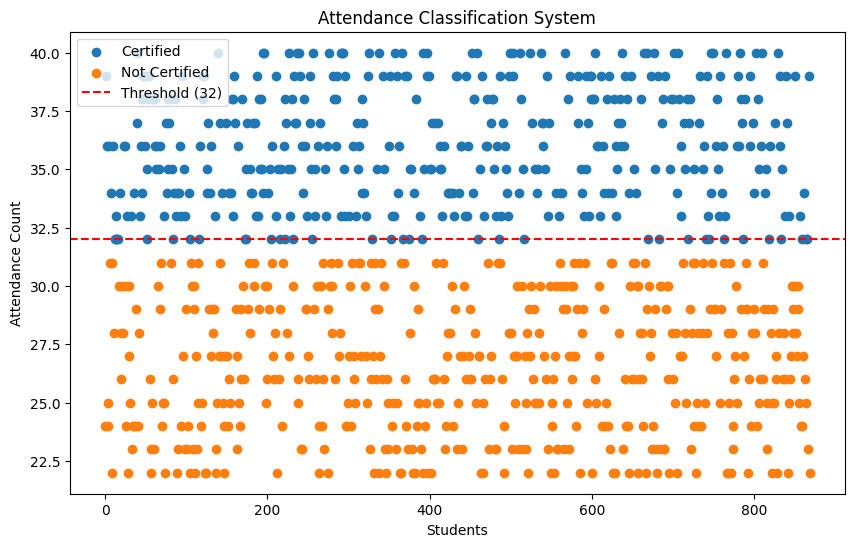

In [ ]:
import matplotlib.pyplot as plt

certified = attendance[
    attendance["Status"] == "Certified"
]

not_certified = attendance[
    attendance["Status"] == "Not Certified"
]

plt.figure(figsize=(10,6))

plt.scatter(
    certified.index,
    certified["Attendance_Count"],
    label="Certified"
)

plt.scatter(
    not_certified.index,
    not_certified["Attendance_Count"],
    label="Not Certified"
)

# Threshold line
plt.axhline(
    y=32,
    color='red',
    linestyle='--',
    label='Threshold (32)'
)

plt.xlabel("Students")
plt.ylabel("Attendance Count")
plt.title("Attendance Classification System")

plt.legend()

plt.show()

In [ ]:
total_students = len(attendance)

certified = (attendance["Status"] == "Certified").sum()

not_certified = (attendance["Status"] == "Not Certified").sum()

print("Total Students:", total_students)
print("Certified Students:", certified)
print("Not Certified Students:", not_certified)
print("Certification Threshold: 32 out of 40 sessions")

Total Students: 869
Certified Students: 406
Not Certified Students: 463
Certification Threshold: 32 out of 40 sessions


In [ ]:
attendance.to_excel(
    "Attendance_Result.xlsx",
    index=False
)

print("File Created")

File Created


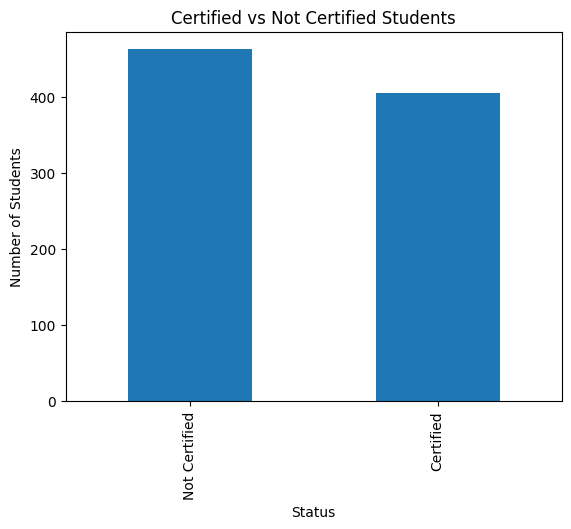

In [ ]:
import matplotlib.pyplot as plt

attendance["Status"].value_counts().plot(kind="bar")

plt.title("Certified vs Not Certified Students")
plt.xlabel("Status")
plt.ylabel("Number of Students")

plt.show()